Training MarkovAutoregression...
Filtering Out-of-Sample Data...


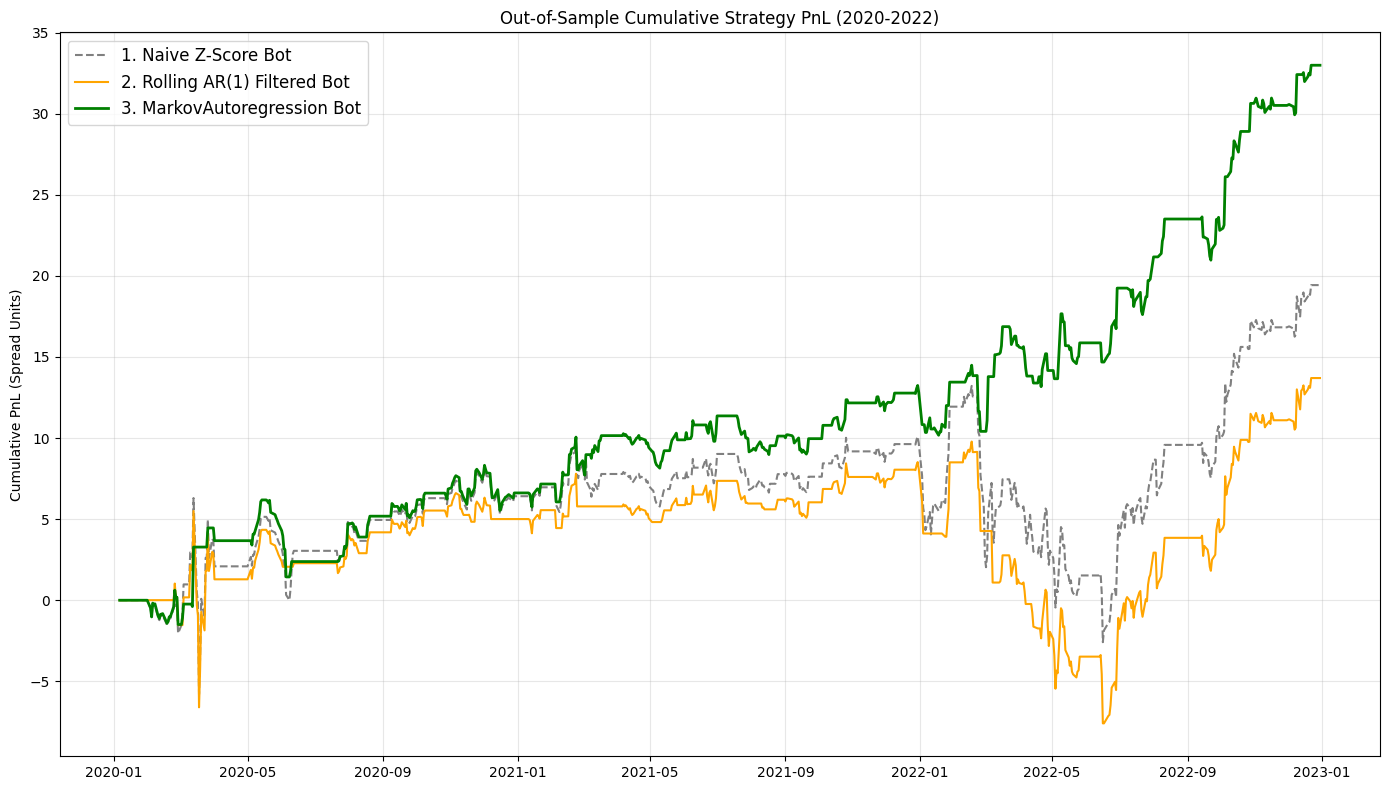


=== FINAL OOS PnL SCORES ===
Naive Bot:               19.43
AR(1) Filtered Bot:      13.70
MarkovAutoregression:    32.99


In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.regime_switching.markov_autoregression import MarkovAutoregression
import warnings

warnings.filterwarnings('ignore')

# ------------------------------------------------------------
# 1. Fetch Data & Rolling OLS Spread
# ------------------------------------------------------------
print("Downloading Data and Building Rolling Spread...")
xom = yf.download("XOM", start="2018-01-01", end="2023-01-01", progress=False)
cvx = yf.download("CVX", start="2018-01-01", end="2023-01-01", progress=False)
col = 'Adj Close' if 'Adj Close' in xom.columns else 'Close'

data = pd.concat([xom[col], cvx[col]], axis=1)
data.columns = ['XOM', 'CVX']
data = data.dropna()

window = 60
spread_series = pd.Series(index=data.index, dtype=float)
for i in range(window, len(data)):
    y_hist = data['XOM'].iloc[i-window:i]
    x_hist = sm.add_constant(data['CVX'].iloc[i-window:i])
    ols_model = sm.OLS(y_hist, x_hist).fit()
    current_x = np.array([1.0, data['CVX'].iloc[i]])
    spread_series.iloc[i] = data['XOM'].iloc[i] - np.dot(current_x, ols_model.params)

data['Spread'] = spread_series
data = data.dropna()

# ------------------------------------------------------------
# 2. Train Model (2018 - 2019)
# ------------------------------------------------------------
train = data.loc[:'2019-12-31']
test = data.loc['2020-01-01':].copy()

print("Training MarkovAutoregression...")
# The specialized Autoregression class prevents singular matrix crashes
ms_ar_model = MarkovAutoregression(train['Spread'], k_regimes=2, order=1, trend="c", 
                                   switching_ar=True, switching_trend=True, switching_variance=True)
ms_ar_res = ms_ar_model.fit(search_reps=20, disp=False)

# Identify Danger State (Highest Variance)
params_ar = dict(zip(ms_ar_res.model.param_names, ms_ar_res.params))
danger_state = 0 if params_ar.get('sigma2[0]', 0) > params_ar.get('sigma2[1]', 0) else 1

# ------------------------------------------------------------
# 3. Filter OOS Data (2020 - 2022)
# ------------------------------------------------------------
print("Filtering Out-of-Sample Data...")

# Filter MS-Autoregression (Strict OOS No Look-Ahead)
test_ms_ar = MarkovAutoregression(test['Spread'], k_regimes=2, order=1, trend="c", 
                                  switching_ar=True, switching_trend=True, switching_variance=True)
res_ar = test_ms_ar.filter(ms_ar_res.params)

probs = res_ar.filtered_marginal_probabilities
if isinstance(probs, pd.DataFrame):
    probs = probs.values
prob_ar = probs[:, danger_state]

# Fast Rolling AR(1) calculation for the Baseline AR Bot
cov = test['Spread'].rolling(30).cov(test['Spread'].shift(1))
var = test['Spread'].shift(1).rolling(30).var()
rolling_ar = cov / var

# ------------------------------------------------------------
# 4. Trading Logic For All 3 Bots
# ------------------------------------------------------------
test_aligned = test.iloc[1:].copy()
test_aligned['Z_Score'] = (test_aligned['Spread'] - test_aligned['Spread'].rolling(20).mean()) / test_aligned['Spread'].rolling(20).std()
test_aligned['Rolling_AR'] = rolling_ar.iloc[1:]
test_aligned['Prob_AR'] = prob_ar

# Position Arrays
pos_naive, pos_ar, pos_ar_ms = np.zeros(len(test_aligned)), np.zeros(len(test_aligned)), np.zeros(len(test_aligned))
current_base = 0.0

for i in range(len(test_aligned)):
    z = test_aligned['Z_Score'].iloc[i]
    r_ar = test_aligned['Rolling_AR'].iloc[i]
    p_ar = test_aligned['Prob_AR'].iloc[i]
    
    if np.isnan(z): continue
        
    # Standard Mean-Reversion Logic
    if z > 1.5: current_base = -1.0
    elif z < -1.5: current_base = 1.0
    elif abs(z) < 0.2: current_base = 0.0
        
    # Bot 1: Naive Bot (Trades blindly)
    pos_naive[i] = current_base
    
    # Bot 2: AR(1) Dynamic Bot (Halt if random walking > 0.95)
    if r_ar > 0.95 or np.isnan(r_ar): pos_ar[i] = 0.0
    else: pos_ar[i] = current_base
        
    # Bot 3: MarkovAutoregression Bot (Scales based on regime probability)
    if p_ar > 0.50: 
        pos_ar_ms[i] = 0.0
    elif p_ar > 0.20: 
        pos_ar_ms[i] = current_base * 0.5
    else: 
        pos_ar_ms[i] = current_base

test_aligned['PnL_Naive'] = pd.Series(pos_naive).shift(1).values * test_aligned['Spread'].diff()
test_aligned['PnL_AR'] = pd.Series(pos_ar).shift(1).values * test_aligned['Spread'].diff()
test_aligned['PnL_AR_MS'] = pd.Series(pos_ar_ms).shift(1).values * test_aligned['Spread'].diff()

# ------------------------------------------------------------
# 5. Plot the Horse Race
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(14, 8))

ax.plot(test_aligned.index, test_aligned['PnL_Naive'].cumsum(), label='1. Naive Z-Score Bot', color='gray', linestyle='--')
ax.plot(test_aligned.index, test_aligned['PnL_AR'].cumsum(), label='2. Rolling AR(1) Filtered Bot', color='orange')
ax.plot(test_aligned.index, test_aligned['PnL_AR_MS'].cumsum(), label='3. MarkovAutoregression Bot', color='green', linewidth=2)

ax.set_title('Out-of-Sample Cumulative Strategy PnL (2020-2022)')
ax.set_ylabel('Cumulative PnL (Spread Units)')
ax.legend(loc='upper left', fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print Final Scores
print("\n=== FINAL OOS PnL SCORES ===")
print(f"Naive Bot:               {test_aligned['PnL_Naive'].sum():.2f}")
print(f"AR(1) Filtered Bot:      {test_aligned['PnL_AR'].sum():.2f}")
print(f"MarkovAutoregression:    {test_aligned['PnL_AR_MS'].sum():.2f}")